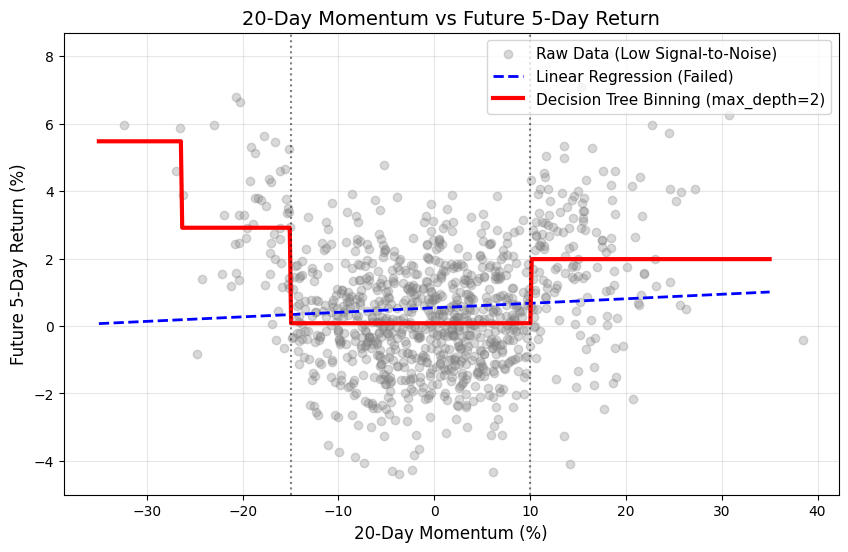

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. 生成带有非线性特征的模拟金融数据
# ==========================================
np.random.seed(42)
n_samples = 1000

# 模拟 20日动量 (单位: %)，范围大致在 -30 到 +30 之间
mom_20 = np.random.normal(0, 10, n_samples) 

# 模拟 未来5日收益率 (单位: %)
# 逻辑设定：
# 1. 极度超卖 (mom_20 < -15): 触发均值回归，未来收益显著为正
# 2. 震荡区间 (-15 <= mom_20 < 10): 噪音大，无明显趋势，未来收益接近 0
# 3. 强势动量 (mom_20 >= 10): 趋势延续，未来收益为正
future_ret = np.zeros(n_samples)

mask_oversold = mom_20 < -15
mask_noise = (mom_20 >= -15) & (mom_20 < 10)
mask_momentum = mom_20 >= 10

# 加入正态分布噪音，模拟真实市场的低信噪比
future_ret[mask_oversold] = 2.5 + np.random.normal(0, 2.0, size=sum(mask_oversold))
future_ret[mask_noise] = 0.0 + np.random.normal(0, 1.5, size=sum(mask_noise))
future_ret[mask_momentum] = 1.8 + np.random.normal(0, 2.0, size=sum(mask_momentum))

# ==========================================
# 2. 模型拟合：线性回归 vs 决策树(分域)
# ==========================================
X = mom_20.reshape(-1, 1)
y = future_ret

# 线性回归 (作为 Baseline)
lr = LinearRegression()
lr.fit(X, y)

# 决策树回归 (限制 max_depth=2，刚好切分出3到4个域)
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X, y)

# ==========================================
# 3. 可视化展现
# ==========================================
# 生成平滑的测试集用于画预测线
X_test = np.linspace(-35, 35, 500).reshape(-1, 1)
y_pred_lr = lr.predict(X_test)
y_pred_tree = tree.predict(X_test)

plt.figure(figsize=(10, 6))

# 散点图：真实的底层数据分布
plt.scatter(X, y, alpha=0.3, color='gray', label='Raw Data (Low Signal-to-Noise)')

# 线性回归预测线
plt.plot(X_test, y_pred_lr, color='blue', linestyle='--', linewidth=2, label='Linear Regression (Failed)')

# 决策树分域预测线 (阶跃函数)
plt.plot(X_test, y_pred_tree, color='red', linewidth=3, label='Decision Tree Binning (max_depth=2)')

plt.axvline(x=-15, color='black', linestyle=':', alpha=0.5)
plt.axvline(x=10, color='black', linestyle=':', alpha=0.5)

plt.title('20-Day Momentum vs Future 5-Day Return', fontsize=14)
plt.xlabel('20-Day Momentum (%)', fontsize=12)
plt.ylabel('Future 5-Day Return (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import numpy as np
import pandas as pd

# 假设 tree 是我们在上一步训练好的 DecisionTreeRegressor(max_depth=2)
# X 是原始的 20日动量数据

def extract_tree_thresholds(model):
    """从 sklearn 决策树中提取所有切分阈值并排序"""
    thresholds = model.tree_.threshold[model.tree_.threshold != -2] # -2 表示叶子节点
    return sorted(thresholds)

# 1. 自动获取阈值
breakpoints = extract_tree_thresholds(tree)
print(f"提取到的分域阈值: {breakpoints}")

# 2. 根据阈值进行分域处理 (使用 pd.cut)
# 我们需要添加负无穷和正无穷来闭合区间
bins = [-np.inf] + breakpoints + [np.inf]
labels = [f"Regime_{i+1}" for i in range(len(bins)-1)]

# 3. 转化为新的分域特征
df_features = pd.DataFrame({'Mom_20': X.flatten()})
df_features['Mom_Regime'] = pd.cut(df_features['Mom_20'], bins=bins, labels=labels)

# 4. (核心步骤) 转化为 One-Hot 编码，方便线性模型直接调用
df_final = pd.get_dummies(df_features, columns=['Mom_Regime'], prefix='Feature')

print("\n--- 转化后的特征矩阵 (前5行) ---")
print(df_final.head())

提取到的分域阈值: [np.float64(-26.353574752807617), np.float64(-14.943516731262207), np.float64(10.103314399719238)]

--- 转化后的特征矩阵 (前5行) ---
      Mom_20  Feature_Regime_1  Feature_Regime_2  Feature_Regime_3  \
0   4.967142             False             False              True   
1  -1.382643             False             False              True   
2   6.476885             False             False              True   
3  15.230299             False             False             False   
4  -2.341534             False             False              True   

   Feature_Regime_4  
0             False  
1             False  
2             False  
3              True  
4             False  


/var/folders/x4/2796gw0130s_d0f9gtys10680000gn/T/ipykernel_70944/3300080176.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_result = regime_analysis.groupby('Mom_Regime')['Future_Ret'].mean()


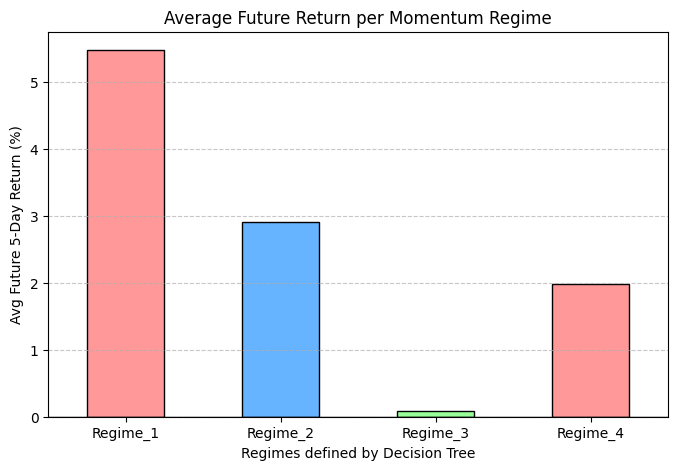

In [20]:
# 计算每个分域的平均未来收益率
regime_analysis = df_features.copy()
regime_analysis['Future_Ret'] = y
analysis_result = regime_analysis.groupby('Mom_Regime')['Future_Ret'].mean()

# 可视化
plt.figure(figsize=(8, 5))
analysis_result.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Future Return per Momentum Regime', fontsize=12)
plt.ylabel('Avg Future 5-Day Return (%)')
plt.xlabel('Regimes defined by Decision Tree')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# 1. 模拟量化数据：特征 (Factor) 与 下期收益率 (Return)
np.random.seed(42)
x = np.random.uniform(-5, 5, 500)
# 假设特征在 [-2, 2] 区间内有显著正向影响，其余区间为噪点或反向
y = np.where((x > -2) & (x < 2), 0.5 * x + 0.1, -0.1 * x) + np.random.normal(0, 0.2, 500)

df = pd.DataFrame({'factor': x, 'return': y})

# 2. 初始化决策树回归器
# 限制 max_leaf_nodes 即为限制最终分桶的数量 (Bins)
# 限制 min_samples_leaf 确保每个桶内有足够的样本量，防止过拟合
tree_binning = DecisionTreeRegressor(max_leaf_nodes=5, min_samples_leaf=50)

# 3. 拟合模型 (单特征分域)
X_input = df[['factor']]
tree_binning.fit(X_input, df['return'])

# 4. 提取分域结果
# 使用 apply() 方法可以获得每个样本所属的叶子节点 ID (即分桶标签)
df['bin_id'] = tree_binning.apply(X_input)

# 5. 结果可视化：展示分域后的各组平均收益
bin_analysis = df.groupby('bin_id')['return'].mean().sort_index()
print("各分桶平均收益率:\n", bin_analysis)

# 可选：查看决策树确定的切分点 (Thresholds)
thresholds = tree_binning.tree_.threshold[tree_binning.tree_.threshold != -2]
print(f"自动发现的切分点: {np.sort(thresholds)}")


各分桶平均收益率:
 bin_id
2   -0.343442
4    0.741903
5    0.338692
7   -0.631751
8    0.067890
Name: return, dtype: float64
自动发现的切分点: [-2.02336395 -0.84985659  0.51691584  2.01468003]


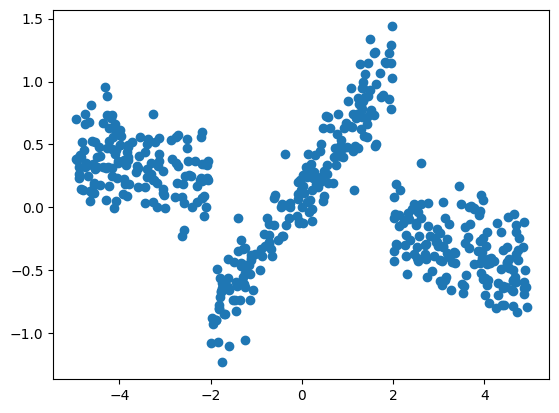

In [10]:
plt.scatter(df['factor'],  df['return'])

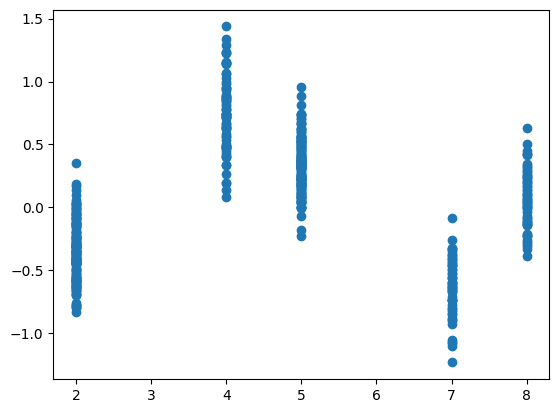

In [8]:
plt.scatter(df['bin_id'], df['return'])